In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os

import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')
import MacSGP_additive

In [2]:
DATA_PATH = "/import/home2/share/yqzeng/MacSGP/data/kidney_cancer" # Raw data
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/results/kidney_cancer" # Deconvolution results
os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)

In [3]:
import torch
model = torch.load(os.path.join(SAVE_PATH, "model_k=10_fix_gamma_k.pt"))

In [ ]:
import torch
model = torch.load(os.path.join(SAVE_PATH, "model_k=10.pt"))

In [4]:
adata_result = model.eval(sort_sgps=False)

In [5]:
#ct_plot = ['B-cell', 'EC', 'Epi_PT', 'Epi_non-PT', 'Fibro', 'Myeloid', 'RCC', 'T-cell']
ct_plot = ['B-cell', 'EC', 'Epi_PT', 'Epi_non-PT', 'Fibro', 'Myeloid', 'RCC', 'T-cell']#, 'Plasma', 'NK', 'pDC', 'Mast']

In [6]:
variance_list = []
for ct in ct_plot:
    variation_ct = []
    for index in range(0, 11):
        variation = adata_result.obsm[ct].values[:, 0:index] @ adata_result.varm[ct].values[:, 0:index].T
        variation_ct.append((variation**2).mean())
    variance_ct = np.array(variation_ct)
    variance_ct = variance_ct / variance_ct[-1]
    variance_list.append(variance_ct)

# get increased variance from 1 to 10 SGPs
variance_explained = []
for variance_ct in variance_list:
    explained = variance_ct[1:] - variance_ct[:-1]
    variance_explained.append(explained)

# variance explained to dataframe
variance_explained_df = pd.DataFrame(variance_explained, index=ct_plot, columns=['SGP_{}'.format(i) for i in range(1, 11)])

In [29]:
basis = model.basis.detach().cpu().numpy()
gamma_k = model.net.gamma_k.detach().cpu().numpy()
basis = basis * np.exp(gamma_k)
proportion = model.proportion.detach().cpu().numpy()
u_exp = proportion @ basis
alpha = model.alpha.detach().cpu().numpy()
gamma = model.gamma.detach().cpu().numpy()
log_lam = np.log(u_exp + 1e-6) + alpha.reshape(-1, 1) + gamma.reshape(1, -1)
# compute decon_loss with log_lam
count = model.Y.detach().cpu().numpy()
library_size = count.sum(axis=1)
# decon_loss_null = - torch.mean(torch.sum(count * 
#                                         (torch.log(library_size + 1e-6) + log_lam) - library_size * torch.exp(log_lam), axis=1))
decon_loss_null = - np.mean(np.sum(count * (np.log(library_size.reshape(-1, 1) + 1e-6) + log_lam) - library_size.reshape(-1, 1) * np.exp(log_lam), axis=1))

# pick decon_loss for each round
decon_loss_all = model.decon_loss
decon_loss_ind = [decon_loss_all[i*3000-1] for i in range(1, 11)]
decon_loss_ind = [decon_loss_null] + decon_loss_ind
decon_loss_ind

[-6005.488,
 -6087.85888671875,
 -6109.35986328125,
 -6123.4951171875,
 -6134.63671875,
 -6143.181640625,
 -6150.60888671875,
 -6156.81884765625,
 -6162.7763671875,
 -6168.275390625,
 -6173.34375]

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr
from libpysal.weights import KNN
import matplotlib as mpl

# ============================================================
# 全局绘图风格设置 (Nature Communications 标准)
# ============================================================
mpl.rcParams.update({
    'font.family': 'Helvetica',  # 使用 Helvetica 字体
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,       # 嵌入字体，便于编辑
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

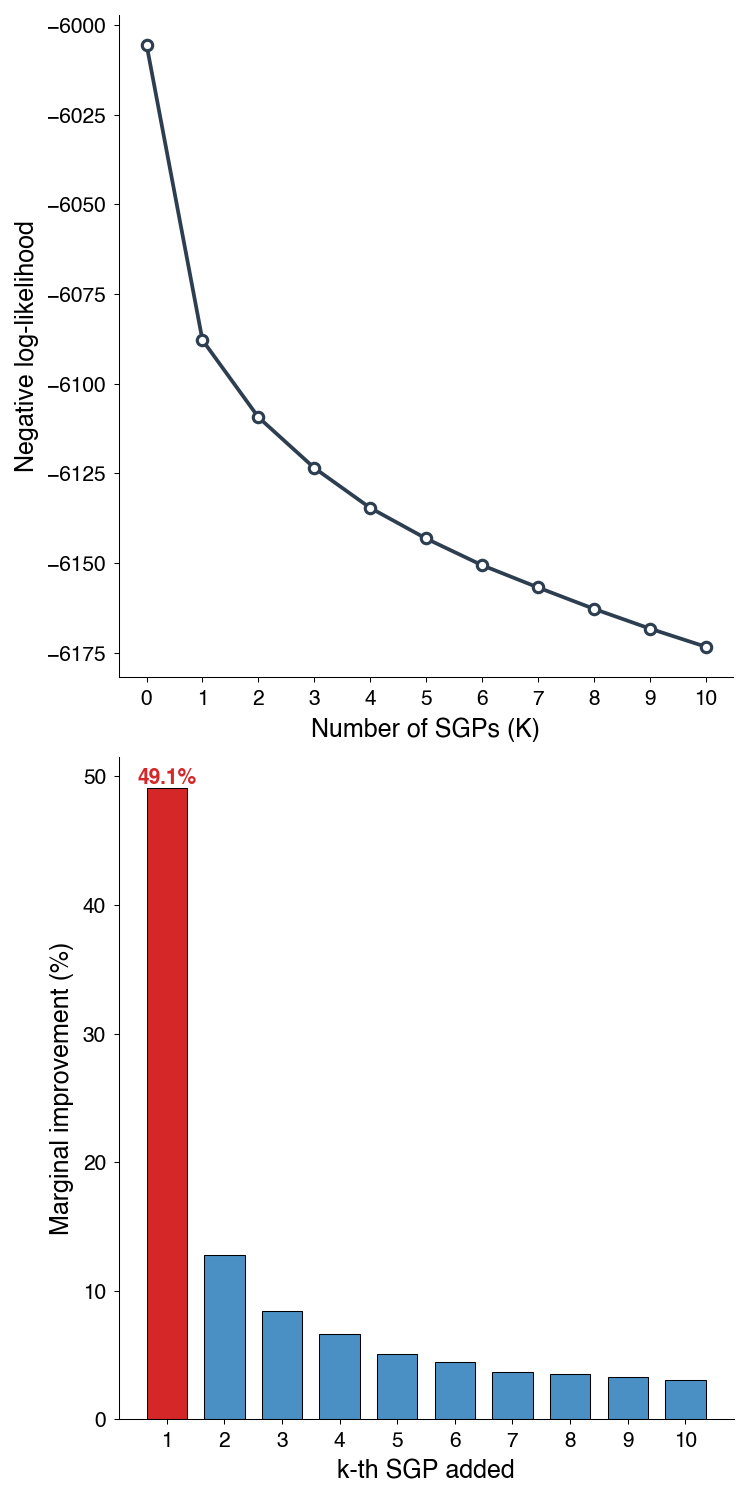

In [19]:
import numpy as np
import matplotlib.pyplot as plt

losses = np.array(decon_loss_ind)

total_improvement = losses[-1] - losses[0]
marginal_gains = np.diff(losses)
marginal_pde = (marginal_gains / total_improvement) * 100

fig, axes = plt.subplots(2, 1, figsize=(5, 10))

# ---- 左图: -Log-likelihood 折线图 ----
axes[0].plot(range(0, len(losses)), losses, 'o-', color='#2c3e50', markersize=5, 
             linewidth=1.8, markerfacecolor='white', markeredgewidth=1.5)
axes[0].set_xlabel('Number of SGPs (K)', fontsize=12)
axes[0].set_ylabel('Negative log-likelihood', fontsize=12)
axes[0].set_xticks(range(0, len(losses)))
axes[0].tick_params(axis='both', labelsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# # 标注K=1处的elbow
# axes[0].annotate('', xy=(1, -losses[1]), xytext=(1.8, -losses[1] + (-losses).max() * 0.08),
#                  arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5))
# axes[0].text(1.85, -losses[1] + (-losses).max() * 0.085, 'K = 1', color='#d62728', 
#              fontsize=10, fontweight='bold')

# ---- 右图: Marginal Deviance Explained 柱状图 ----
bar_colors = ['#d62728'] + ['#4a90c4'] * (len(marginal_pde) - 1)
bars = axes[1].bar(range(1, len(marginal_pde) + 1), marginal_pde, 
                   color=bar_colors, edgecolor='black', linewidth=0.5, width=0.7)
axes[1].set_xlabel('k-th SGP added', fontsize=12)
axes[1].set_ylabel('Marginal improvement (%)', fontsize=12)
axes[1].set_xticks(range(1, len(marginal_pde) + 1))
axes[1].tick_params(axis='both', labelsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# 在第一个柱子上方标注
axes[1].annotate(f'{marginal_pde[0]:.1f}%', xy=(1, marginal_pde[0]),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#d62728')

# # 子图标签 (a) (b)
# axes[0].text(-0.15, 1.05, 'a', transform=axes[0].transAxes, fontsize=14, fontweight='bold')
# axes[1].text(-0.15, 1.05, 'b', transform=axes[1].transAxes, fontsize=14, fontweight='bold')

plt.tight_layout(w_pad=3)
# plt.savefig('K_selection_deviance.pdf', dpi=300, bbox_inches='tight')
plt.show()

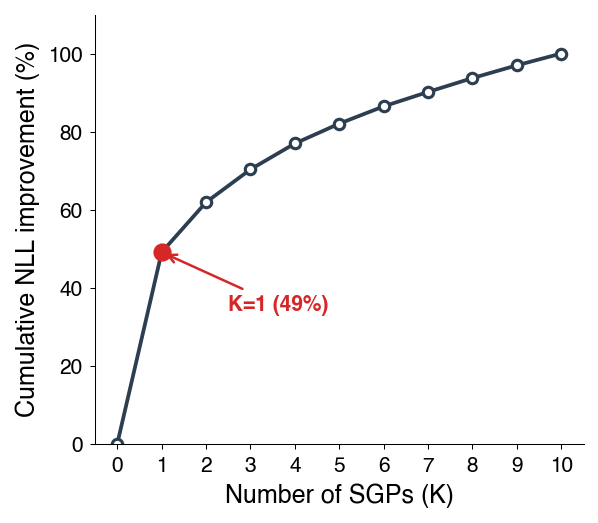

Kidney: K=1 cumulative = 49.1%, K=3 cumulative = 70.3%


In [30]:
import numpy as np
import matplotlib.pyplot as plt

losses = np.array(decon_loss_ind)

total_improvement = losses[-1] - losses[0]
marginal_gains = np.diff(losses)
cumulative_pde = np.cumsum(marginal_gains / total_improvement * 100)
cumulative_pde = np.concatenate([[0], cumulative_pde])

fig, ax = plt.subplots(1, 1, figsize=(4, 3.5))

ax.plot(range(0, len(cumulative_pde)), cumulative_pde, 'o-',
        color='#2c3e50', markersize=5, linewidth=1.8,
        markerfacecolor='white', markeredgewidth=1.5)

# highlight K=1 as the elbow
ax.scatter([1], [cumulative_pde[1]], color='#d62728', s=60, zorder=5)
ax.annotate(f'K=1 ({cumulative_pde[1]:.0f}%)',
            xy=(1, cumulative_pde[1]),
            xytext=(2.5, cumulative_pde[1] - 15),
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.2),
            color='#d62728', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of SGPs (K)', fontsize=12)
ax.set_ylabel('Cumulative NLL improvement (%)', fontsize=12)
ax.set_xticks(range(0, len(cumulative_pde)))
ax.set_ylim(0, 110)
ax.tick_params(axis='both', labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('scree_plot_kidney.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Kidney: K=1 cumulative = {cumulative_pde[1]:.1f}%, K=3 cumulative = {cumulative_pde[3]:.1f}%")

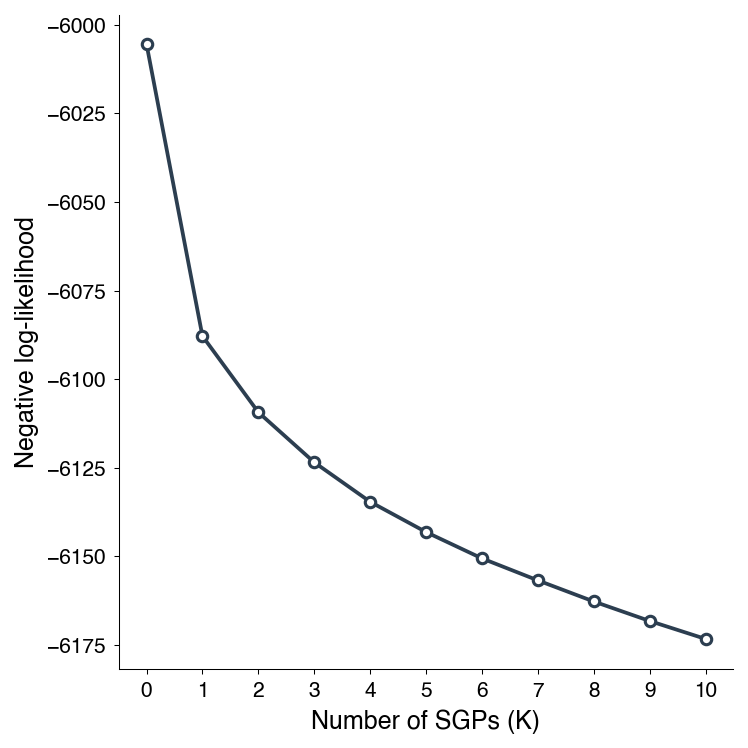

In [9]:
import numpy as np
import matplotlib.pyplot as plt

losses = np.array(decon_loss_ind)

total_improvement = losses[-1] - losses[0]
marginal_gains = np.diff(losses)
marginal_pde = (marginal_gains / total_improvement) * 100

fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# ---- 左图: -Log-likelihood 折线图 ----
axes.plot(range(0, len(losses)), losses, 'o-', color='#2c3e50', markersize=5, 
             linewidth=1.8, markerfacecolor='white', markeredgewidth=1.5)
axes.set_xlabel('Number of SGPs (K)', fontsize=12)
axes.set_ylabel('Negative log-likelihood', fontsize=12)
axes.set_xticks(range(0, len(losses)))
axes.tick_params(axis='both', labelsize=10)
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

plt.tight_layout(w_pad=3)
# plt.savefig('K_selection_deviance.pdf', dpi=300, bbox_inches='tight')
plt.show()

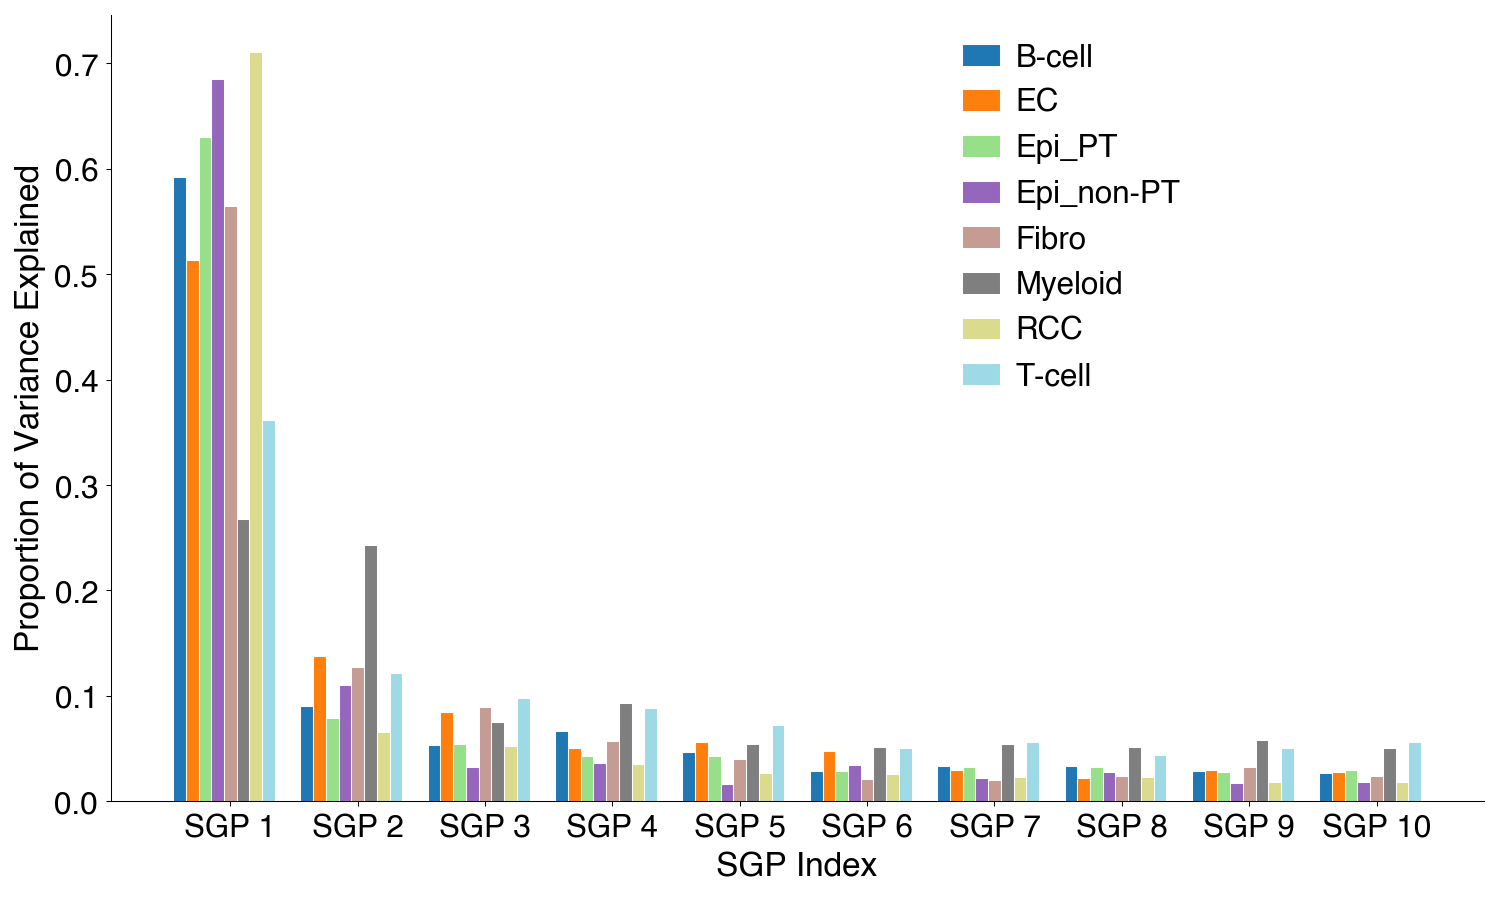

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

n_ct = len(ct_plot)
n_sgp = 10
bar_width = 0.8 / n_ct
index = np.arange(n_sgp)
cmap = plt.cm.get_cmap('tab20', n_ct)

for j in range(n_ct):
    explained_j = [variance_explained[j][i] for i in range(n_sgp)]
    ax.bar(index + j * bar_width, explained_j, bar_width,
           label=ct_plot[j], color=cmap(j), edgecolor='white', linewidth=0.5)

ax.set_xlabel('SGP Index', fontsize=16)
ax.set_ylabel('Proportion of Variance Explained', fontsize=16)
ax.set_xticks(index + bar_width * n_ct / 2)
ax.set_xticklabels([f'SGP {i+1}' for i in range(n_sgp)], fontsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(bbox_to_anchor=(0.60, 1), loc='upper left',
          frameon=False, fontsize=15, handlelength=1.2, handletextpad=0.5)

plt.tight_layout()
plt.show()

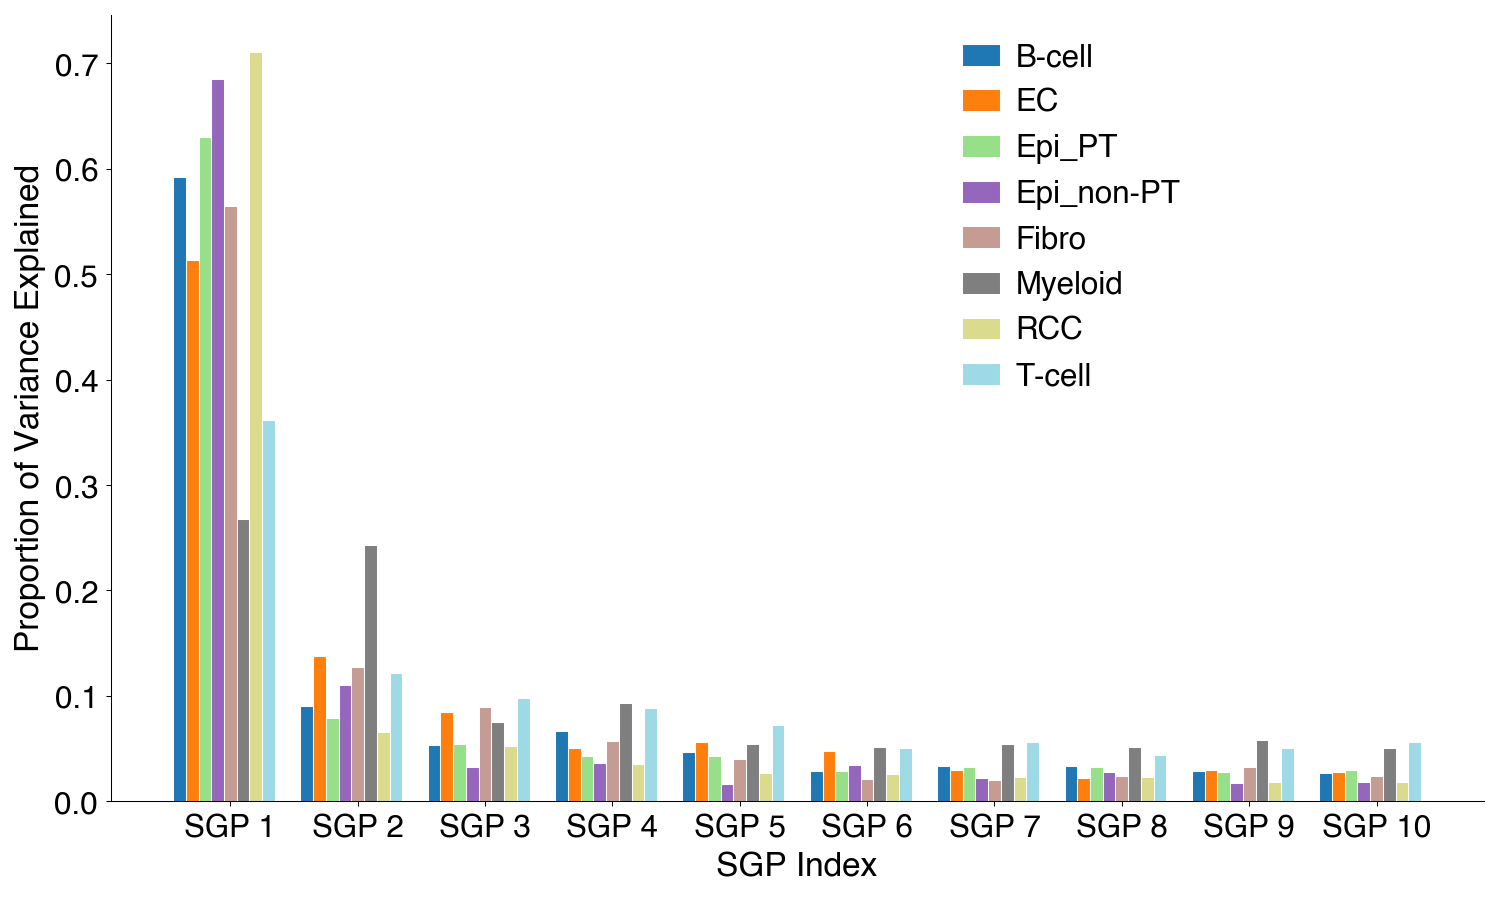

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

n_ct = len(ct_plot)
n_sgp = 10
bar_width = 0.8 / n_ct
index = np.arange(n_sgp)
cmap = plt.cm.get_cmap('tab20', n_ct)

for j in range(n_ct):
    explained_j = [variance_explained[j][i] for i in range(n_sgp)]
    ax.bar(index + j * bar_width, explained_j, bar_width,
           label=ct_plot[j], color=cmap(j), edgecolor='white', linewidth=0.5)

ax.set_xlabel('SGP Index', fontsize=16)
ax.set_ylabel('Proportion of Variance Explained', fontsize=16)
ax.set_xticks(index + bar_width * n_ct / 2)
ax.set_xticklabels([f'SGP {i+1}' for i in range(n_sgp)], fontsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(bbox_to_anchor=(0.60, 1), loc='upper left',
          frameon=False, fontsize=15, handlelength=1.2, handletextpad=0.5)

plt.tight_layout()
plt.show()

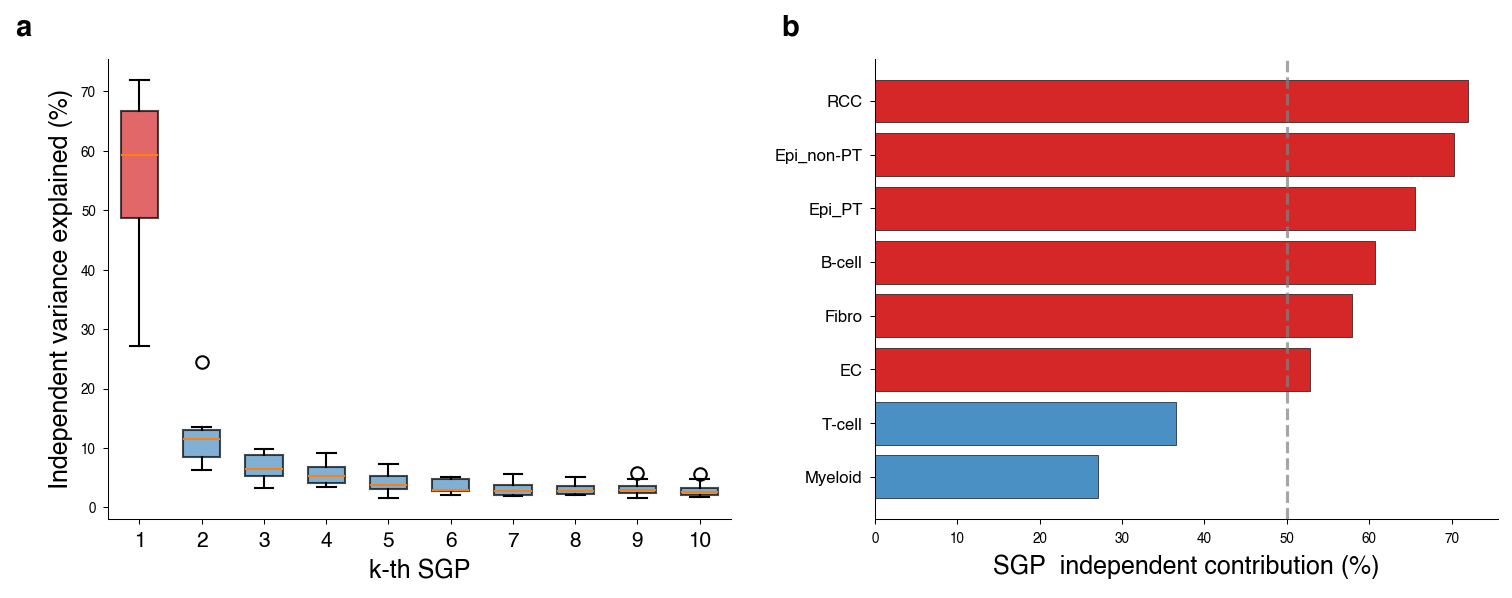

SGP_1 independent contribution:
  Mean:   55.4%
  Median: 59.3%
  Min:    27.1% (Myeloid)
  Max:    72.0% (RCC)
  % cell types with SGP_1 > 50%: 6/8


In [11]:
variance_list_independent = []
for ct in ct_plot:
    F_ct = adata_result.obsm[ct].values   # N x K
    L_ct = adata_result.varm[ct].values   # G x K (or K x G, check your convention)
    
    independent_var = []
    for k in range(F_ct.shape[1]):
        recon_k = np.outer(F_ct[:, k], L_ct[:, k])  # rank-1 reconstruction from k-th SGP alone
        independent_var.append((recon_k ** 2).mean())
    
    independent_var = np.array(independent_var)
    # 归一化：每个SGP占总独立贡献的比例
    independent_var = independent_var / independent_var.sum()
    variance_list_independent.append(independent_var)

variance_independent_df = pd.DataFrame(
    variance_list_independent, 
    index=ct_plot, 
    columns=['SGP_{}'.format(i) for i in range(1, F_ct.shape[1] + 1)]
)

# ---- 可视化 ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# (a) Boxplot: 每个SGP position的独立贡献分布
sgp_data = [variance_independent_df.iloc[:, i].values * 100 for i in range(10)]
bp = axes[0].boxplot(sgp_data, patch_artist=True, widths=0.6)
box_colors = ['#d62728'] + ['#4a90c4'] * 9
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_xlabel('k-th SGP', fontsize=12)
axes[0].set_ylabel('Independent variance explained (%)', fontsize=12)
axes[0].set_xticklabels(range(1, 11), fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# (b) 横向bar: SGP_1的独立贡献，按cell type排序
sgp1_pct = variance_independent_df['SGP_1'].values * 100
sorted_idx = np.argsort(sgp1_pct)
colors_bar = ['#d62728' if v >= 50 else '#4a90c4' for v in sgp1_pct[sorted_idx]]
axes[1].barh(range(len(ct_plot)), sgp1_pct[sorted_idx], color=colors_bar, edgecolor='black', linewidth=0.3)
axes[1].set_yticks(range(len(ct_plot)))
axes[1].set_yticklabels(np.array(ct_plot)[sorted_idx], fontsize=8)
axes[1].set_xlabel('SGP₁ independent contribution (%)', fontsize=12)
axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.7)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[0].text(-0.15, 1.05, 'a', transform=axes[0].transAxes, fontsize=14, fontweight='bold')
axes[1].text(-0.15, 1.05, 'b', transform=axes[1].transAxes, fontsize=14, fontweight='bold')

plt.tight_layout(w_pad=3)
plt.show()

# ---- 统计 ----
sgp1 = variance_independent_df['SGP_1'].values * 100
print("=" * 60)
print(f"SGP_1 independent contribution:")
print(f"  Mean:   {sgp1.mean():.1f}%")
print(f"  Median: {np.median(sgp1):.1f}%")
print(f"  Min:    {sgp1.min():.1f}% ({ct_plot[np.argmin(sgp1)]})")
print(f"  Max:    {sgp1.max():.1f}% ({ct_plot[np.argmax(sgp1)]})")
print(f"  % cell types with SGP_1 > 50%: {(sgp1 > 50).sum()}/{len(sgp1)}")

In [8]:
delta_matrix_kc

SGP,1,2,3,4,5,6,7,8,9,10
cell_type,,,,,,,,,,
B-cell,4.876953,1.417969,1.045410,1.028320,0.703125,0.572754,0.549316,0.587402,0.530762,0.515625
EC,6.062500,1.957031,1.619629,1.026855,0.998047,1.098145,0.770996,0.801270,0.775879,0.787109
Epi_PT,4.640137,1.364258,0.514648,0.771484,0.761719,0.459473,0.472168,0.451660,0.699707,0.393555
Epi_non-PT,11.523438,2.479980,1.090820,1.252930,0.941406,0.664551,0.738770,0.652832,0.740723,0.990234
Fibro,7.563965,2.458008,1.611816,1.085938,0.991211,0.647949,0.665039,0.709961,0.724121,0.900879
Myeloid,3.026855,5.439453,1.602539,1.796387,0.975586,1.108398,1.215820,1.087402,1.068848,0.904297
RCC,28.210938,3.581055,2.554688,1.968750,1.646484,1.517090,1.354004,1.407715,1.088379,1.283203
T-cell,1.785645,0.596191,0.899414,0.513672,0.601074,0.400391,0.392578,0.410156,0.435059,0.395508


In [11]:
delta_matrix_kc.sum().sum()

145.95605

In [9]:
delta_matrix_kc.sum(axis=1)

cell_type
B-cell        11.827637
EC            15.897461
Epi_PT        10.528809
Epi_non-PT    21.075684
Fibro         17.358887
Myeloid       18.225586
RCC           44.612305
T-cell         6.429688
dtype: float32

Kidney cancer — within-celltype normalized ΔNLL (row sums to 1):
SGP            1      2      3      4      5      6      7      8      9      10
cell_type                                                                       
B-cell      0.413  0.115  0.089  0.089  0.060  0.049  0.047  0.049  0.045  0.044
EC          0.383  0.123  0.102  0.068  0.065  0.062  0.050  0.048  0.050  0.049
Epi_PT      0.444  0.126  0.069  0.053  0.073  0.061  0.047  0.046  0.044  0.038
Epi_non-PT  0.548  0.117  0.059  0.051  0.040  0.045  0.037  0.036  0.036  0.031
Fibro       0.436  0.141  0.093  0.062  0.057  0.047  0.038  0.042  0.042  0.042
Myeloid     0.311  0.168  0.096  0.085  0.064  0.058  0.059  0.057  0.053  0.049
RCC         0.638  0.075  0.055  0.044  0.037  0.034  0.031  0.032  0.029  0.025
T-cell      0.279  0.140  0.091  0.091  0.081  0.063  0.065  0.061  0.067  0.062


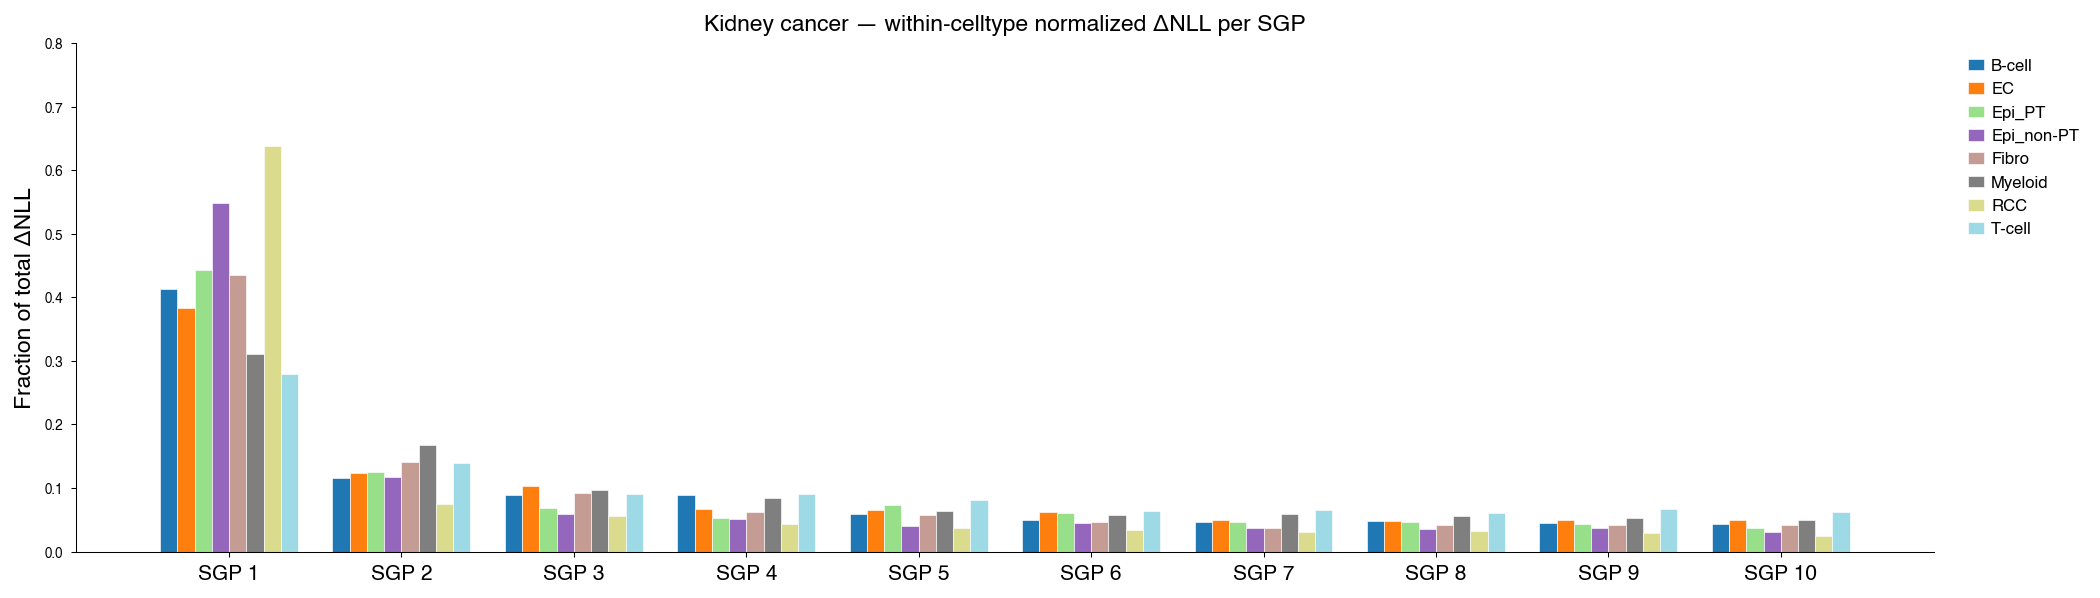


Mean SGP-1 fraction: 0.432


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Sequential marginal NLL — within-celltype normalized, grouped bar ─────────

# Recompute prerequisites
basis_adj_kc = model.basis.detach().cpu().numpy()
gamma_k_np_kc = model.net.gamma_k.detach().cpu().numpy()
basis_adj_kc = basis_adj_kc * np.exp(gamma_k_np_kc)

proportion_np_kc = model.proportion.detach().cpu().numpy()
alpha_np_kc = model.alpha.detach().cpu().numpy()
gamma_np_kc = model.gamma.detach().cpu().numpy()
count_np_kc = model.Y.detach().cpu().numpy()
library_size_np_kc = count_np_kc.sum(axis=1)
celltypes_all_kc = list(adata_result.obsm['proportion'].columns)

def compute_nll_kc(log_lam):
    return -np.mean(np.sum(
        count_np_kc * (np.log(library_size_np_kc.reshape(-1, 1) + 1e-6) + log_lam)
        - library_size_np_kc.reshape(-1, 1) * np.exp(log_lam),
        axis=1))

u_base_dict_kc = {}
for c_idx, ct_i in enumerate(celltypes_all_kc):
    u_base_dict_kc[ct_i] = (proportion_np_kc[:, c_idx:c_idx+1]
                             * basis_adj_kc[c_idx:c_idx+1, :])

K_kc = adata_result.obsm[ct_plot[0]].shape[1]

u_exp_c_at_k_kc = {}
for ct_i in celltypes_all_kc:
    u_base_c = u_base_dict_kc[ct_i]
    u_exp_c_at_k_kc[ct_i] = {0: u_base_c.copy()}
    if ct_i in adata_result.obsm and isinstance(adata_result.obsm[ct_i], pd.DataFrame):
        F_c = adata_result.obsm[ct_i].values
        L_c = adata_result.varm[ct_i].values
        for k in range(1, K_kc + 1):
            u_exp_c_at_k_kc[ct_i][k] = u_base_c * np.exp(F_c[:, :k] @ L_c[:, :k].T)
    else:
        for k in range(1, K_kc + 1):
            u_exp_c_at_k_kc[ct_i][k] = u_base_c.copy()

u_total_at_k_kc = {}
for k in range(K_kc + 1):
    u_total_at_k_kc[k] = sum(u_exp_c_at_k_kc[ct_i][k] for ct_i in celltypes_all_kc)

records_kc = []
for k in range(1, K_kc + 1):
    u_base_k = u_total_at_k_kc[k - 1]
    log_lam_base = (np.log(u_base_k + 1e-6)
                    + alpha_np_kc.reshape(-1, 1)
                    + gamma_np_kc.reshape(1, -1))
    nll_base = compute_nll_kc(log_lam_base)
    for ct_i in ct_plot:
        u_new = (u_base_k
                 - u_exp_c_at_k_kc[ct_i][k - 1]
                 + u_exp_c_at_k_kc[ct_i][k])
        log_lam_new = (np.log(u_new + 1e-6)
                       + alpha_np_kc.reshape(-1, 1)
                       + gamma_np_kc.reshape(1, -1))
        nll_new = compute_nll_kc(log_lam_new)
        records_kc.append({'cell_type': ct_i, 'SGP': k, 'delta_nll': nll_base - nll_new})

seq_df_kc = pd.DataFrame(records_kc)
delta_matrix_kc = seq_df_kc.pivot(index='cell_type', columns='SGP', values='delta_nll')
delta_norm_kc = delta_matrix_kc.div(delta_matrix_kc.sum(axis=1), axis=0).loc[ct_plot]

print("Kidney cancer — within-celltype normalized ΔNLL (row sums to 1):")
print(delta_norm_kc.round(3).to_string())

# ── Grouped bar chart ────────────────────────────────────────────────────────
n_ct  = len(delta_norm_kc)
n_sgp = delta_norm_kc.shape[1]
bar_width = 0.8 / n_ct
x = np.arange(n_sgp)
cmap_ct = plt.cm.get_cmap('tab20', n_ct)

fig, ax = plt.subplots(figsize=(14, 4))
for i, ct_i in enumerate(delta_norm_kc.index):
    offsets = x + (i - n_ct / 2 + 0.5) * bar_width
    ax.bar(offsets, delta_norm_kc.loc[ct_i].values,
           width=bar_width, color=cmap_ct(i),
           edgecolor='white', linewidth=0.3, label=ct_i)

ax.set_xticks(x)
ax.set_xticklabels([f'SGP {k}' for k in delta_norm_kc.columns], fontsize=10)
ax.set_ylabel('Fraction of total ΔNLL', fontsize=11)
ax.set_title('Kidney cancer — within-celltype normalized ΔNLL per SGP', fontsize=11)
ax.set_ylim(0, 0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=8, frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left',
          handlelength=1.0, handletextpad=0.4)

plt.tight_layout()
# plt.savefig('seq_marginal_bar_kidney.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMean SGP-1 fraction: {delta_norm_kc.iloc[:, 0].mean():.3f}")


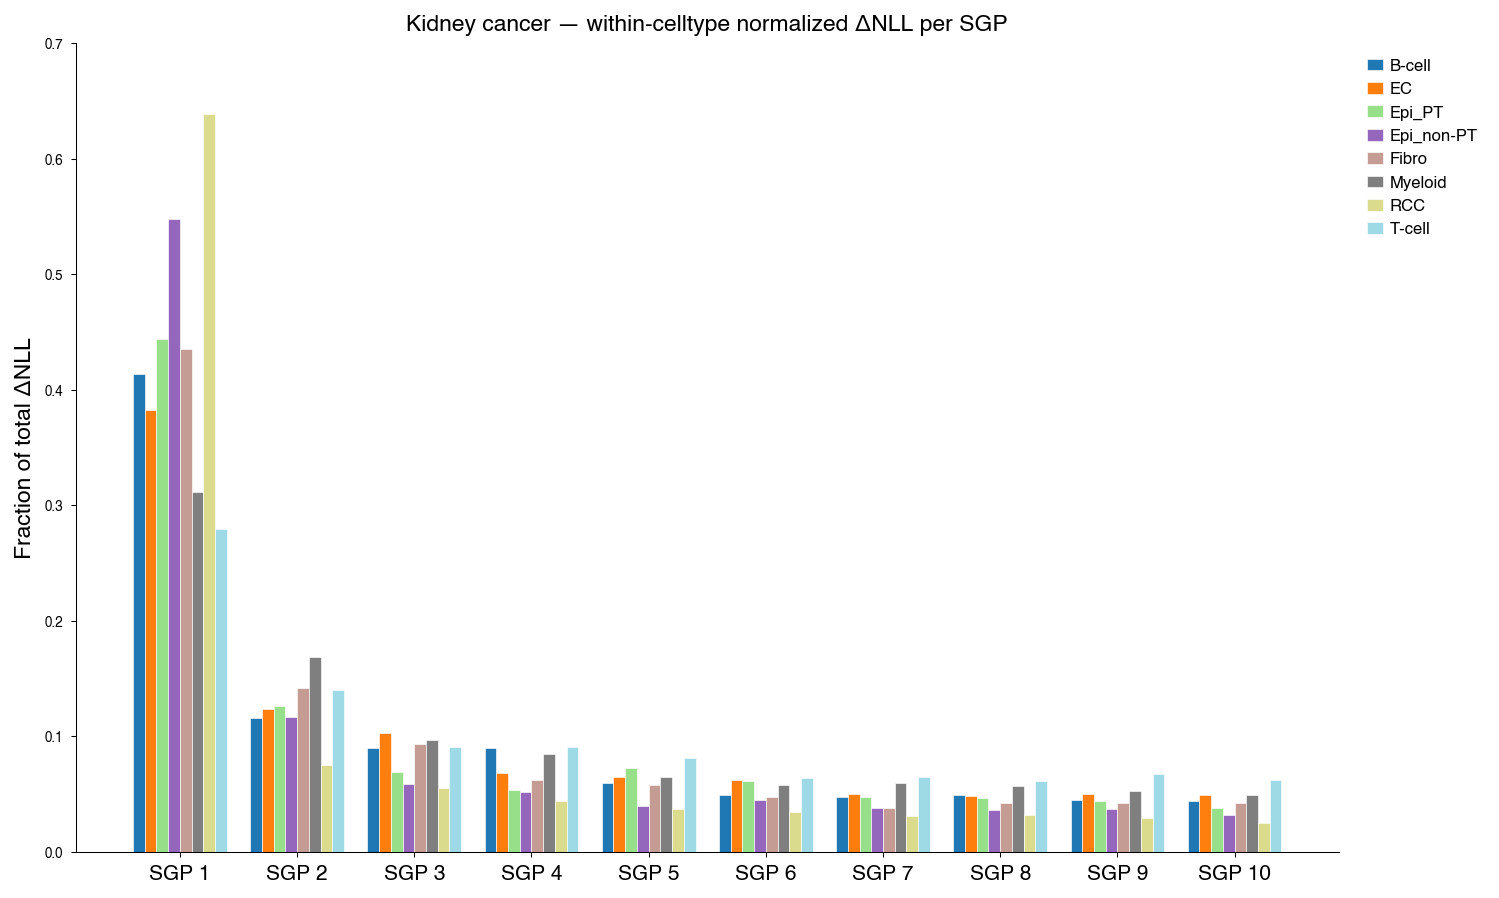


Mean SGP-1 fraction: 0.432


In [33]:
# ── Grouped bar chart ────────────────────────────────────────────────────────
n_ct  = len(delta_norm_kc)
n_sgp = delta_norm_kc.shape[1]
bar_width = 0.8 / n_ct
x = np.arange(n_sgp)
cmap_ct = plt.cm.get_cmap('tab20', n_ct)

fig, ax = plt.subplots(figsize=(10, 6))
for i, ct_i in enumerate(delta_norm_kc.index):
    offsets = x + (i - n_ct / 2 + 0.5) * bar_width
    ax.bar(offsets, delta_norm_kc.loc[ct_i].values,
           width=bar_width, color=cmap_ct(i),
           edgecolor='white', linewidth=0.3, label=ct_i)

ax.set_xticks(x)
ax.set_xticklabels([f'SGP {k}' for k in delta_norm_kc.columns], fontsize=10)
ax.set_ylabel('Fraction of total ΔNLL', fontsize=11)
ax.set_title('Kidney cancer — within-celltype normalized ΔNLL per SGP', fontsize=11)
ax.set_ylim(0, 0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=8, frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left',
          handlelength=1.0, handletextpad=0.4)

plt.tight_layout()
# plt.savefig('seq_marginal_bar_kidney.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMean SGP-1 fraction: {delta_norm_kc.iloc[:, 0].mean():.3f}")

In [11]:
# cumulative_variance
cum_variance_df = variance_explained_df.cumsum(axis=1)

In [9]:
cum_variance_df

,SGP_1,SGP_2,SGP_3,SGP_4,SGP_5,SGP_6,SGP_7,SGP_8,SGP_9,SGP_10
B-cell,0.592002,0.682200,0.735829,0.802209,0.849332,0.877609,0.911143,0.944517,0.972842,1.0
EC,0.513645,0.651739,0.736786,0.787634,0.844003,0.891929,0.921041,0.943478,0.972662,1.0
Epi_PT,0.630631,0.709530,0.763915,0.806591,0.849189,0.877651,0.910319,0.942857,0.970534,1.0
Epi_non-PT,0.685410,0.795669,0.828173,0.864679,0.881009,0.915635,0.937639,0.964929,0.981710,1.0
Fibro,0.564970,0.692040,0.781361,0.838913,0.878826,0.899400,0.919609,0.943561,0.976410,1.0
Myeloid,0.267657,0.511190,0.586770,0.679739,0.734188,0.785467,0.839987,0.891301,0.949622,1.0
RCC,0.710917,0.777014,0.829542,0.865198,0.892194,0.917928,0.940666,0.963750,0.981648,1.0
T-cell,0.361823,0.483679,0.581969,0.670190,0.742861,0.793317,0.849261,0.893272,0.943671,1.0


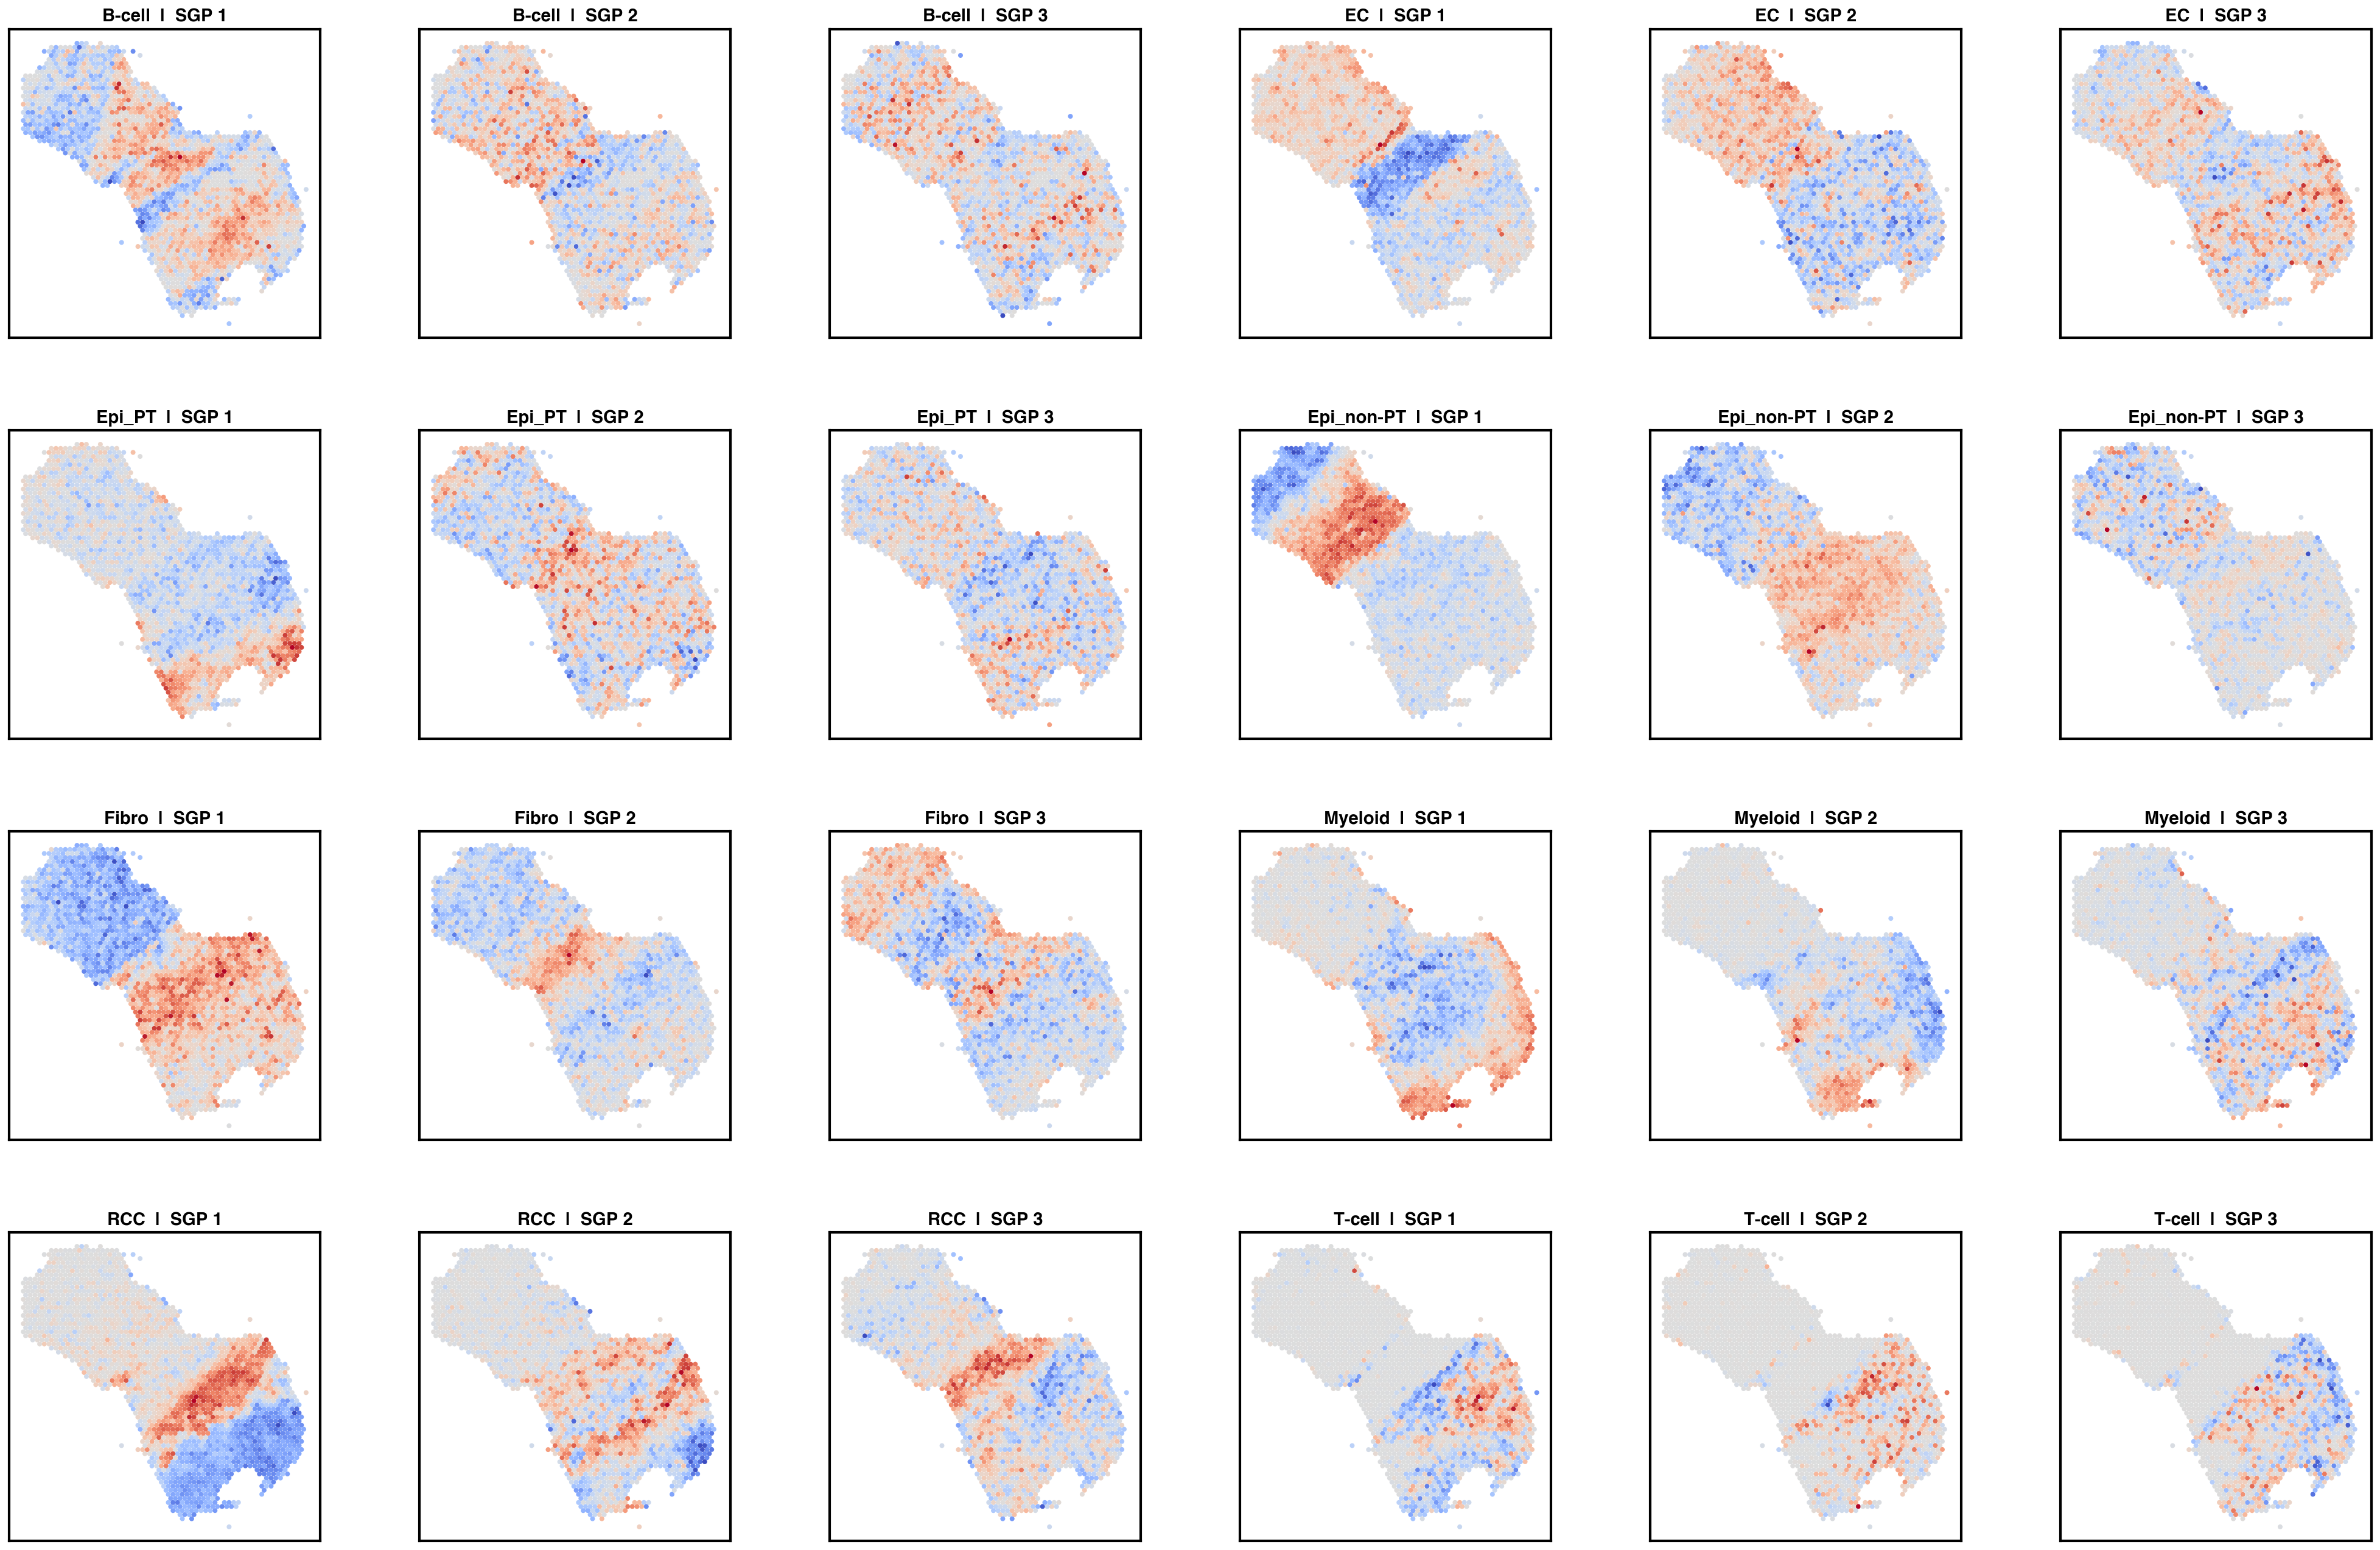

In [34]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

selected_cts = ct_plot  # 按需修改
n_sgps = 3              # 每个 cell type 画前 3 个 SGP
cts_per_row = 2         # 每行放 2 个 cell type
ncols = cts_per_row * n_sgps  # 6 列
nrows = int(np.ceil(len(selected_cts) / cts_per_row))
cmap = 'coolwarm'

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))

# 当只有一行时，保证 axes 是二维数组
if nrows == 1:
    axes = axes[np.newaxis, :]

for idx, ct in enumerate(selected_cts):
    row = idx // cts_per_row
    col_offset = (idx % cts_per_row) * n_sgps

    data = adata_result.obsm[ct].values  # shape: (N, K)

    for j in range(min(n_sgps, data.shape[1])):
        ax = axes[row, col_offset + j]
        values = data[:, j]
        norm_ij = mpl.colors.TwoSlopeNorm(vcenter=0.0)

        sca = ax.scatter(
            adata_result.obsm["spatial"][:, 0],
            adata_result.obsm["spatial"][:, 1],
            c=values,
            s=8,
            cmap=cmap,
            norm=norm_ij,
        )
        ax.set_title(f'{ct}  |  SGP {j + 1}', fontsize=14, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal', adjustable='box')
        for spine in ax.spines.values():
            spine.set_linewidth(2)

        # # 每个子图右侧加 colorbar
        # cbar = fig.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)
        # cbar.ax.tick_params(labelsize=9)

# 隐藏多余的空白子图
total_used = len(selected_cts)
if total_used % cts_per_row != 0:
    remainder = cts_per_row - (total_used % cts_per_row)
    for r in range(remainder):
        for j in range(n_sgps):
            axes[nrows - 1, (cts_per_row - remainder + r) * n_sgps + j].axis('off')

fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.02,
                    wspace=0.30, hspace=0.30)
plt.show()

In [12]:
cum_variance_df

,SGP_1,SGP_2,SGP_3,SGP_4,SGP_5,SGP_6,SGP_7,SGP_8,SGP_9,SGP_10
B-cell,0.592002,0.682200,0.735829,0.802209,0.849332,0.877609,0.911143,0.944517,0.972842,1.0
EC,0.513645,0.651739,0.736786,0.787634,0.844003,0.891929,0.921041,0.943478,0.972662,1.0
Epi_PT,0.630631,0.709530,0.763915,0.806591,0.849189,0.877651,0.910319,0.942857,0.970534,1.0
Epi_non-PT,0.685410,0.795669,0.828173,0.864679,0.881009,0.915635,0.937639,0.964929,0.981710,1.0
Fibro,0.564970,0.692040,0.781361,0.838913,0.878826,0.899400,0.919609,0.943561,0.976410,1.0
Myeloid,0.267657,0.511190,0.586770,0.679739,0.734188,0.785467,0.839987,0.891301,0.949622,1.0
RCC,0.710917,0.777014,0.829542,0.865198,0.892194,0.917928,0.940666,0.963750,0.981648,1.0
T-cell,0.361823,0.483679,0.581969,0.670190,0.742861,0.793317,0.849261,0.893272,0.943671,1.0


In [56]:
LOADING_CT = adata_result.varm['Myeloid']
LOADING_CT['loading_2'].nsmallest(10)

MT2A     -0.885753
FN1      -0.860579
IL32     -0.834247
TAPBP    -0.802619
CXCL9    -0.799793
CX3CR1   -0.781278
IDO1     -0.760460
MNDA     -0.692450
NCL      -0.688851
CXCL10   -0.680315
Name: loading_2, dtype: float32

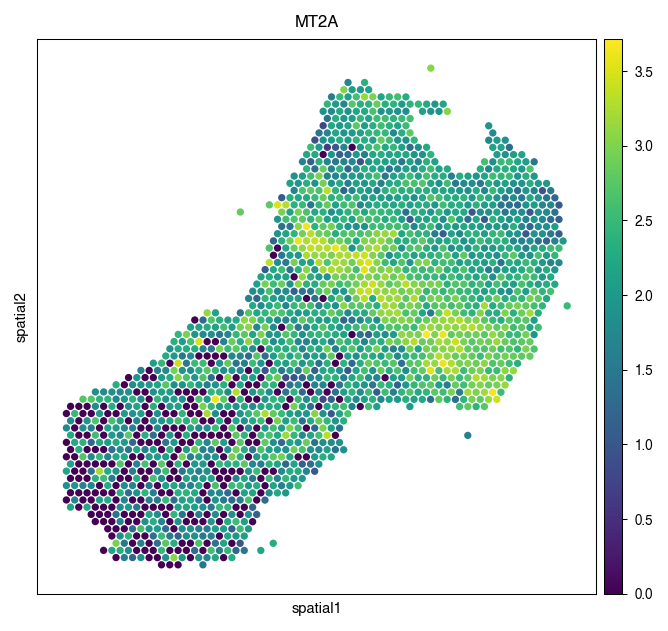

In [57]:
sc.pl.spatial(adata_result, color='MT2A', spot_size=100, img_key=None)

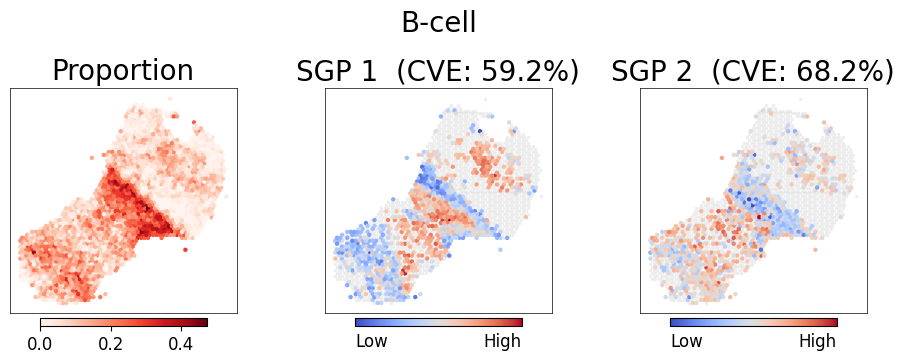

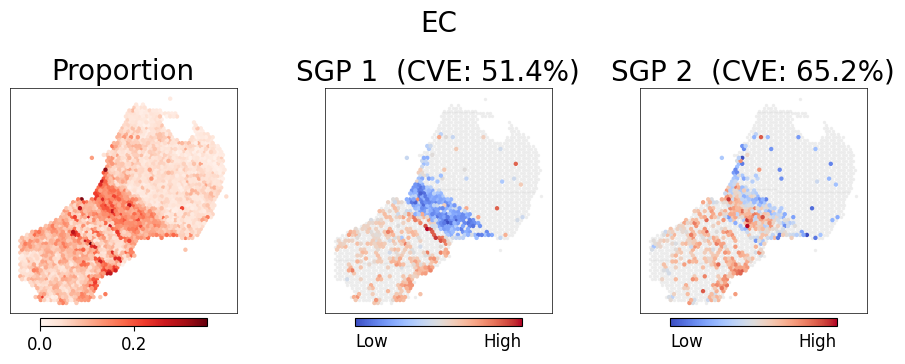

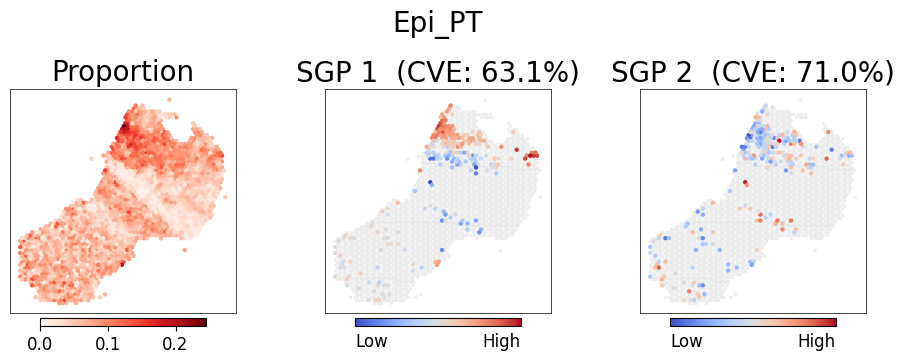

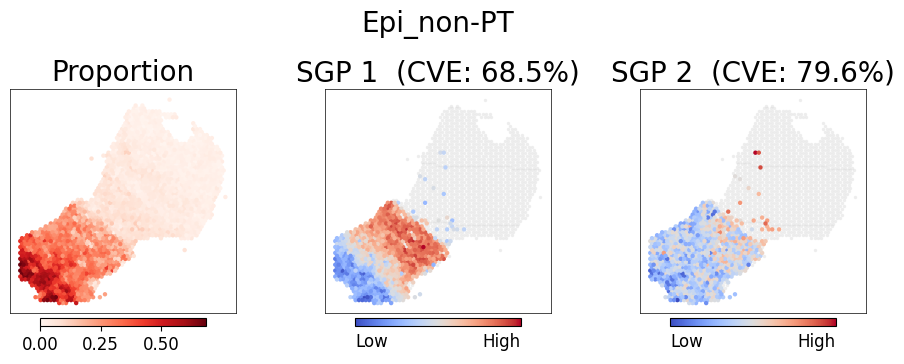

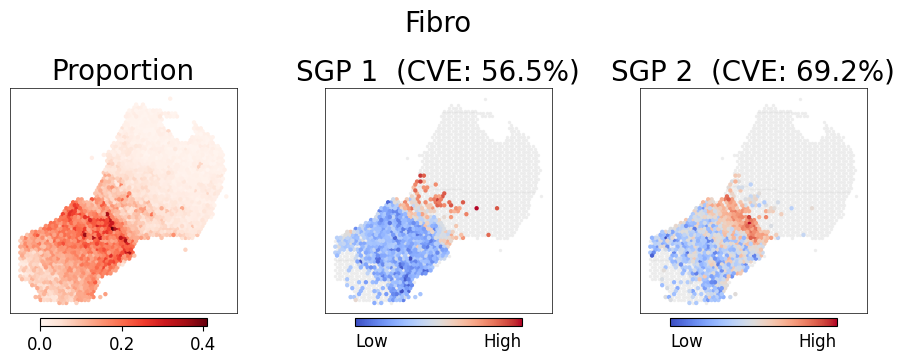

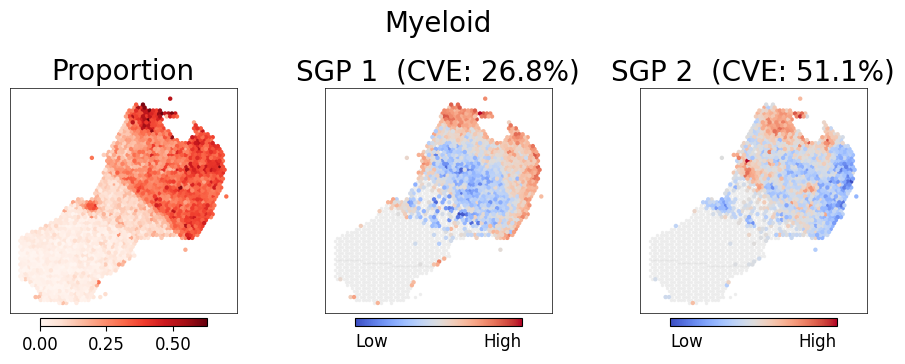

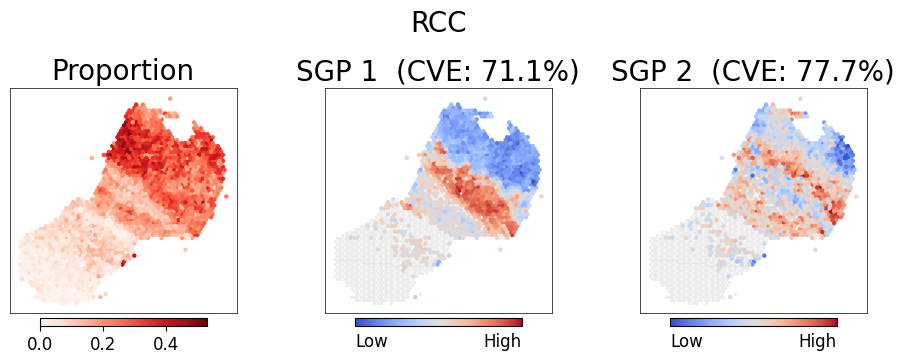

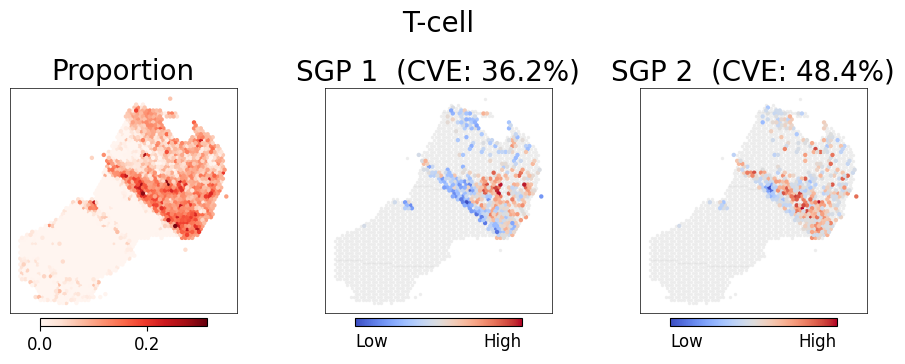

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# 参数
# ============================================================
selected_cts   = ['RCC', 'Epi_non-PT', 'Epi_PT', 'Myeloid', 'Fibro']
selected_cts   = ct_plot
cum_threshold  = 0.60
prop_threshold = 0.1

cmap_sgp  = 'coolwarm'
cmap_prop = 'Reds'
s_vis    = 10
s_masked = 6

spatial = adata_result.obsm["spatial"]

for ct in selected_cts:
    n_sgp   = 2
    n_cols  = n_sgp + 1          # proportion + SGP1 + SGP2
    cum_row = cum_variance_df.loc[ct].values

    prop = adata_result.obsm['proportion'][ct].to_numpy()
    mask = prop >= prop_threshold
    data = adata_result.obsm[ct].values   # (N, K)

    fig, axes = plt.subplots(1, n_cols,
                             figsize=(3.2 * n_cols, 3.5),
                             squeeze=False)
    axes = axes[0]

    # ── 第 0 列：proportion 分布图 ──────────────────────────────────────
    ax0 = axes[0]
    sca0 = ax0.scatter(spatial[:, 0], -spatial[:, 1],
                       c=prop, s=s_vis, cmap=cmap_prop,
                       vmin=0, vmax=prop.max(),
                       rasterized=True, linewidths=0)
    cbar0 = fig.colorbar(sca0, ax=ax0, orientation='horizontal',
                         fraction=0.035, pad=0.02, shrink=0.6)
    cbar0.ax.tick_params(labelsize=12)
    ax0.set_title('Proportion', fontsize=20)
    ax0.set_xticks([]); ax0.set_yticks([])
    ax0.set_aspect('equal', adjustable='box')
    for spine in ax0.spines.values():
        spine.set_linewidth(0.5)

    # ── 第 1..n_sgp 列：SGP 空间图 ─────────────────────────────────────
    for j in range(n_sgp):
        ax      = axes[j + 1]
        values  = data[:, j]
        norm_ij = mpl.colors.TwoSlopeNorm(vcenter=0.0)

        ax.scatter(spatial[~mask, 0], -spatial[~mask, 1],
                   c='lightgray', s=s_masked, alpha=0.4,
                   rasterized=True, linewidths=0)
        sca_j = ax.scatter(spatial[mask, 0], -spatial[mask, 1],
                           c=values[mask], s=s_vis, cmap=cmap_sgp,
                           norm=norm_ij, rasterized=True, linewidths=0)

        cbar_j = fig.colorbar(sca_j, ax=ax, orientation='horizontal',
                              fraction=0.035, pad=0.02, shrink=0.6)
        cbar_j.set_ticks([])
        cbar_j.ax.text(0.0, -0.8, 'Low',  ha='left',  va='top', fontsize=12,
                       transform=cbar_j.ax.transAxes)
        cbar_j.ax.text(1.0, -0.8, 'High', ha='right', va='top', fontsize=12,
                       transform=cbar_j.ax.transAxes)

        cum_pct = cum_row[j] * 100
        ax.set_title(f'SGP {j+1}  (CVE: {cum_pct:.1f}%)', fontsize=20)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect('equal', adjustable='box')
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    fig.suptitle(f'{ct}', fontsize=20, y=1.02)
    plt.subplots_adjust(wspace=0.05)
    plt.tight_layout()
    plt.savefig(f'{ct}_top{n_sgp}_spatial.png', dpi=300, bbox_inches='tight')
    plt.show()


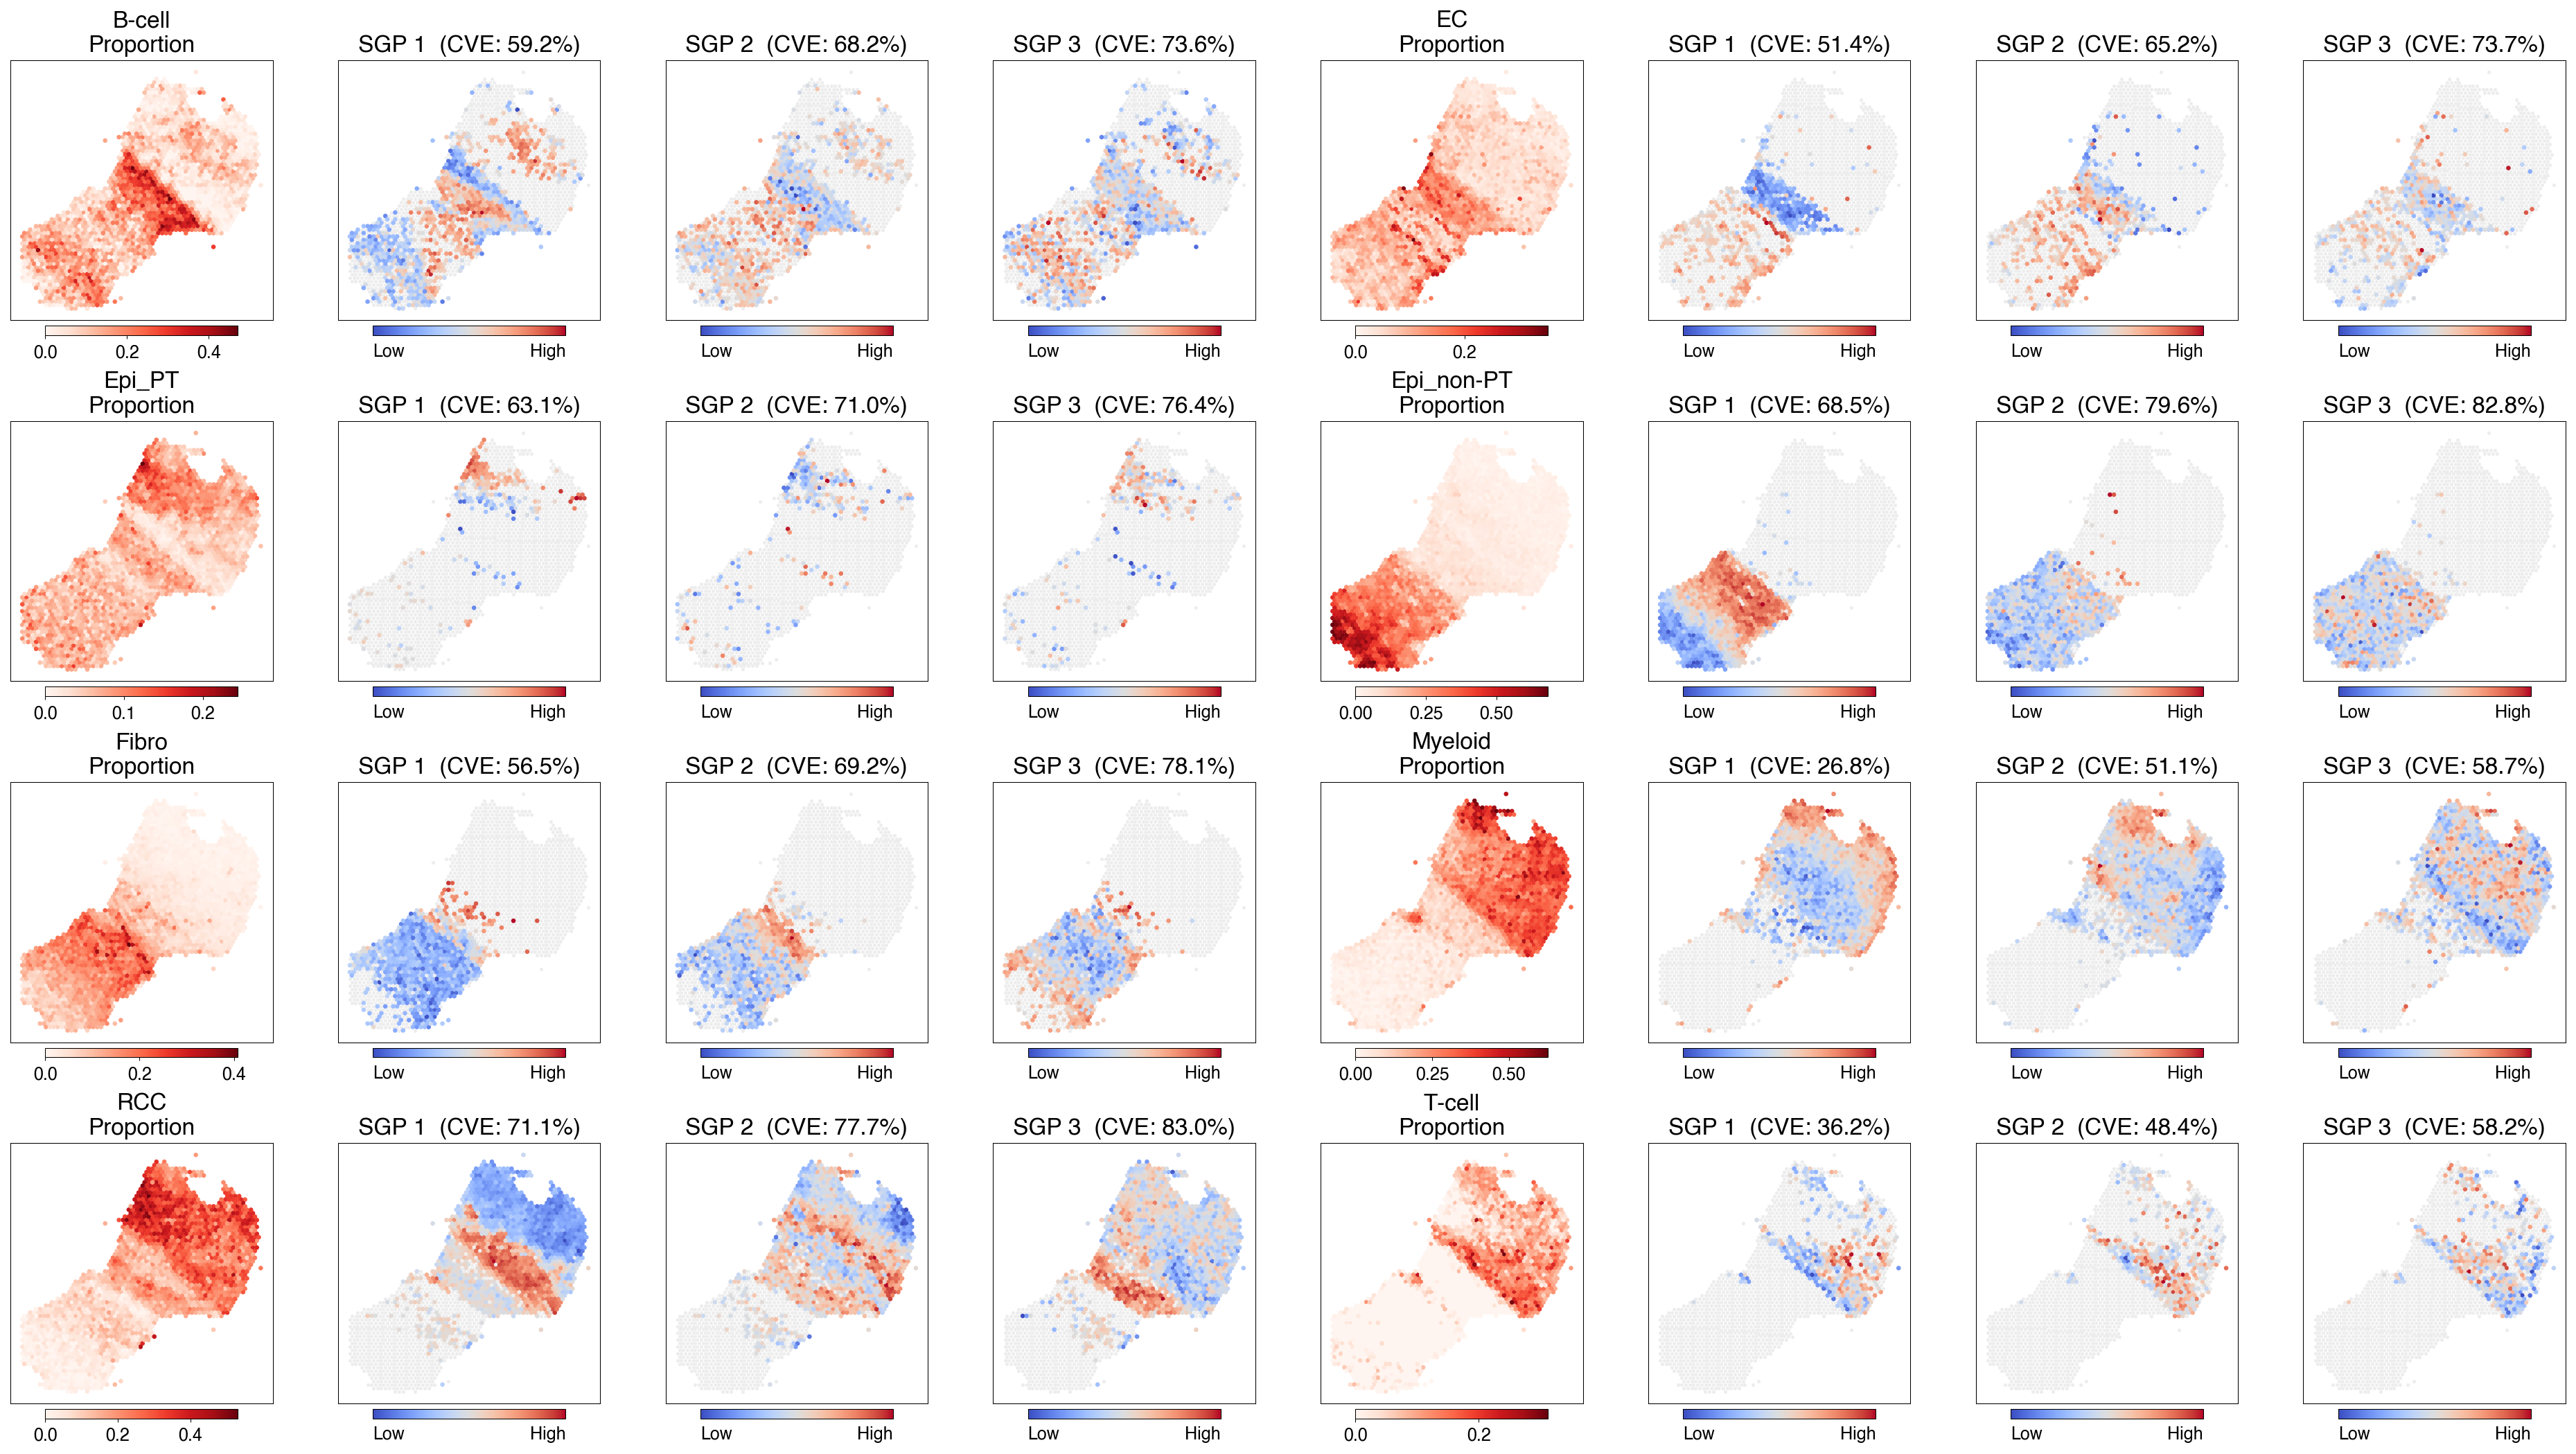

In [12]:
import math

# ============================================================
# 参数
# ============================================================
n_sgp          = 3
cols_per_ct    = n_sgp + 1        # proportion + SGP1..3
cts_per_row    = 2
prop_threshold = 0.1
cmap_sgp       = 'coolwarm'
cmap_prop      = 'Reds'
s_vis          = 10
s_masked       = 6

spatial = adata_result.obsm["spatial"]
selected_cts = ct_plot
n_cts  = len(selected_cts)
n_rows = math.ceil(n_cts / cts_per_row)
n_cols = cols_per_ct * cts_per_row

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(3.2 * n_cols, 3.5 * n_rows),
                         squeeze=False)

for i, ct in enumerate(selected_cts):
    row        = i // cts_per_row
    col_offset = (i % cts_per_row) * cols_per_ct
    cum_row    = cum_variance_df.loc[ct].values
    prop       = adata_result.obsm['proportion'][ct].to_numpy()
    mask       = prop >= prop_threshold
    data       = adata_result.obsm[ct].values

    # proportion 列
    ax0  = axes[row, col_offset]
    sca0 = ax0.scatter(spatial[:, 0], -spatial[:, 1],
                       c=prop, s=s_vis, cmap=cmap_prop,
                       vmin=0, vmax=prop.max(),
                       rasterized=True, linewidths=0)
    cbar0 = fig.colorbar(sca0, ax=ax0, orientation='horizontal',
                         fraction=0.035, pad=0.02, shrink=0.6)
    cbar0.ax.tick_params(labelsize=12)
    ax0.set_title(f'{ct}\nProportion', fontsize=16)
    ax0.set_xticks([]); ax0.set_yticks([])
    ax0.set_aspect('equal', adjustable='box')
    for spine in ax0.spines.values():
        spine.set_linewidth(0.5)

    # SGP 列
    for j in range(n_sgp):
        ax      = axes[row, col_offset + j + 1]
        values  = data[:, j]
        norm_ij = mpl.colors.TwoSlopeNorm(vcenter=0.0)

        ax.scatter(spatial[~mask, 0], -spatial[~mask, 1],
                   c='lightgray', s=s_masked, alpha=0.4,
                   rasterized=True, linewidths=0)
        sca_j = ax.scatter(spatial[mask, 0], -spatial[mask, 1],
                           c=values[mask], s=s_vis, cmap=cmap_sgp,
                           norm=norm_ij, rasterized=True, linewidths=0)

        cbar_j = fig.colorbar(sca_j, ax=ax, orientation='horizontal',
                              fraction=0.035, pad=0.02, shrink=0.6)
        cbar_j.set_ticks([])
        cbar_j.ax.text(0.0, -0.8, 'Low',  ha='left',  va='top', fontsize=12,
                       transform=cbar_j.ax.transAxes)
        cbar_j.ax.text(1.0, -0.8, 'High', ha='right', va='top', fontsize=12,
                       transform=cbar_j.ax.transAxes)

        cum_pct = cum_row[j] * 100
        ax.set_title(f'SGP {j+1}  (CVE: {cum_pct:.1f}%)', fontsize=16)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect('equal', adjustable='box')
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

# 隐藏多余的空白轴（cell type 数为奇数时）
for i in range(n_cts, n_rows * cts_per_row):
    row        = i // cts_per_row
    col_offset = (i % cts_per_row) * cols_per_ct
    for j in range(cols_per_ct):
        axes[row, col_offset + j].set_visible(False)

plt.subplots_adjust(wspace=0.05, hspace=0.3)
plt.tight_layout()
plt.savefig(f'all_cts_top{n_sgp}_spatial.png', dpi=300, bbox_inches='tight')
plt.show()


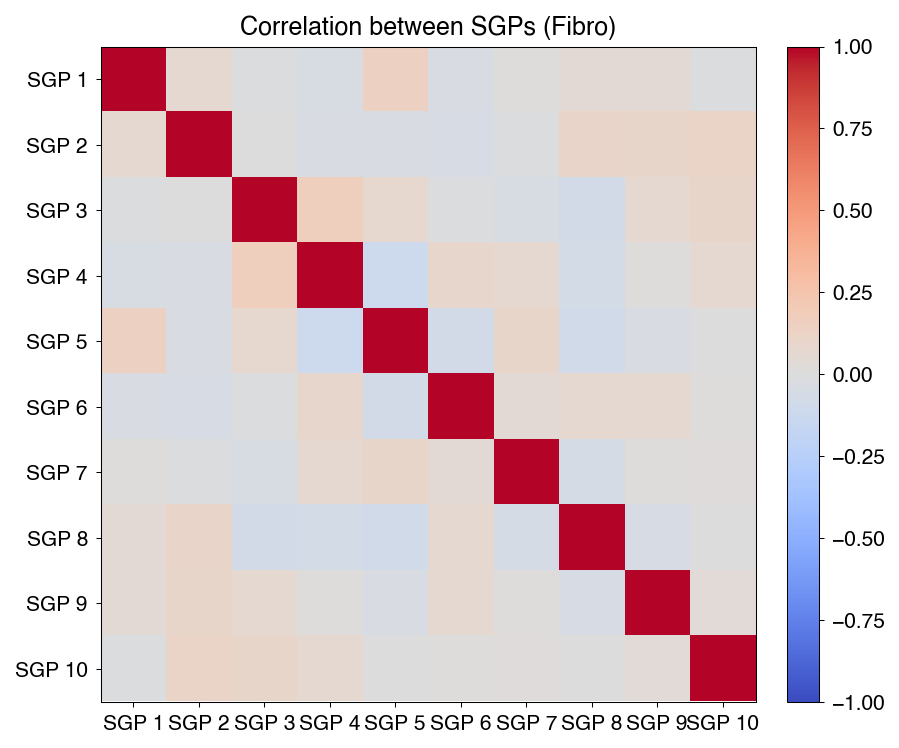

In [30]:
# heatmap of correlation between SGPs
coef = np.corrcoef(adata_result.varm['Fibro'].values.T)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(coef, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(coef.shape[0]))
ax.set_yticks(range(coef.shape[0]))
ax.set_xticklabels([f'SGP {i+1}' for i in range(coef.shape[0])], fontsize=10)
ax.set_yticklabels([f'SGP {i+1}' for i in range(coef.shape[0])], fontsize=10)
ax.set_title('Correlation between SGPs (Fibro)', fontsize=12)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()